# Statistik mit Python: vom Rohdatensatz zur Aussage

**Einstieg für Statistik in der Informatik / Wirtschaftsinformatik**

Heute geht es nicht darum, Python „zu lernen“. Wir benutzen Python als **Werkzeug**, um statistische Fragen an Daten zu stellen.

## Lernziele

Nach diesem Notebook können Sie …

- einen Datensatz in einem Jupyter Notebook laden und inspizieren,
- Zeilen und Spalten auswählen und Daten filtern,
- Häufigkeiten sowie Lage- und Streuungsmaße berechnen,
- Histogramm, Balkendiagramm, Boxplot und Streudiagramm sinnvoll einsetzen,
- Gruppen vergleichen,
- Korrelation vorsichtig interpretieren,
- erklären, warum Stichproben zufällig schwanken.

> **Bedienung:** Eine Zelle mit `Shift` + `Enter` ausführen.  
> Code darf verändert werden – genau dafür ist ein Notebook da.

---

### Die Leitfrage

Wir betrachten Messdaten eines fiktiven Web-Systems. Jede Zeile ist ein API-Request.

**Fragen für heute:**

1. Welche Endpoints werden häufig aufgerufen?
2. Welcher Endpoint ist typischerweise langsam?
3. Wie stark streuen Antwortzeiten?
4. Haben große Payloads längere Antwortzeiten?
5. Macht ein Cache-Hit einen Unterschied?
6. Wie stabil ist ein Mittelwert, wenn wir nur eine Stichprobe beobachten?

## 0. R und Python – unterschiedliche Syntax, gleiche Statistik

Die verlinkte Statistik-Veranstaltung arbeitet überwiegend mit **R**. Hier verwenden wir **Python**.  
Die statistischen Konzepte sind dieselben.

| Aufgabe | R | Python / pandas |
|---|---|---|
| Mittelwert | `mean(x)` | `x.mean()` |
| Median | `median(x)` | `x.median()` |
| Standardabweichung | `sd(x)` | `x.std()` |
| Häufigkeiten | `table(x)` | `x.value_counts()` |
| Zusammenfassung | `summary(x)` | `x.describe()` |
| Histogramm | `hist(x)` | `x.plot.hist()` |
| Gruppieren | `aggregate(...)` / `dplyr` | `groupby(...)` |

**Merksatz:** Statistik ist die Idee – Software ist das Werkzeug.

## 1. Werkzeugkasten laden

Für heute reichen drei verbreitete Pakete:

- `pandas` für Tabellen und Datenmanipulation,
- `numpy` für numerische Operationen und Zufall,
- `matplotlib` für Diagramme.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 20)
plt.rcParams["figure.figsize"] = (8, 4.5)

/home/oai/.config/matplotlib is not a writable directory


Matplotlib created a temporary cache directory at /tmp/matplotlib-ax8xua0k because there was an issue with the default path (/home/oai/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


## 2. Datensatz laden

Der Datensatz liegt als CSV-Datei im Unterordner `data/`.

**Statistische Einheit:** ein API-Request.

Einige Merkmale:

- `endpoint`, `region`: kategorial
- `hour`, `payload_kb`, `response_ms`: quantitativ
- `cache_hit`: binär
- `status_code`: numerisch codiert, inhaltlich aber eher kategorial

In [2]:
df = pd.read_csv("data/api_requests.csv")
df.head()

,request_id,endpoint,region,hour,cache_hit,payload_kb,response_ms,status_code
0,REQ-0001,/login,US-East,10,False,10.4,236.0,200
1,REQ-0002,/checkout,EU-West,17,False,18.5,272.5,500
2,REQ-0003,/checkout,US-East,8,False,14.3,387.5,200
3,REQ-0004,/search,EU-West,19,False,41.5,216.7,200
4,REQ-0005,/cart,EU-West,9,False,16.6,180.1,200


In [3]:
print("Zeilen, Spalten:", df.shape)
print("\nSpalten:")
print(df.columns.to_list())

Zeilen, Spalten: (320, 8)

Spalten:
['request_id', 'endpoint', 'region', 'hour', 'cache_hit', 'payload_kb', 'response_ms', 'status_code']


### Erster Blick auf die Daten

Bevor wir rechnen, prüfen wir Struktur, Datentypen und fehlende Werte.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 320 entries, 0 to 319
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   request_id   320 non-null    object 
 1   endpoint     320 non-null    object 
 2   region       320 non-null    object 
 3   hour         320 non-null    int64  
 4   cache_hit    320 non-null    bool   
 5   payload_kb   320 non-null    float64
 6   response_ms  314 non-null    float64
 7   status_code  320 non-null    int64  
dtypes: bool(1), float64(2), int64(2), object(3)
memory usage: 17.9+ KB


In [5]:
df.isna().sum()

request_id     0
endpoint       0
region         0
hour           0
cache_hit      0
payload_kb     0
response_ms    6
status_code    0
dtype: int64

Wir haben einige fehlende Antwortzeiten. Für die folgenden Analysen arbeiten wir mit einer bereinigten Kopie.

In [6]:
clean = df.dropna(subset=["response_ms"]).copy()
print("Vorher:", len(df), "Zeilen")
print("Nachher:", len(clean), "Zeilen")

Vorher: 320 Zeilen
Nachher: 314 Zeilen


## 3. Daten auswählen und filtern

Das ist für Informatiker:innen oft der intuitivste Einstieg:  
Ein DataFrame ist eine Tabelle, und Bedingungen liefern Wahrheitswerte (`True`/`False`).

In [7]:
# Eine Spalte auswählen
clean["response_ms"].head()

0    236.0
1    272.5
2    387.5
3    216.7
4    180.1
Name: response_ms, dtype: float64

In [8]:
# Alle Serverfehler (HTTP 500)
server_errors = clean[clean["status_code"] == 500]
server_errors[["request_id", "endpoint", "response_ms", "status_code"]].head()

,request_id,endpoint,response_ms,status_code
1,REQ-0002,/checkout,272.5,500
11,REQ-0012,/product,219.6,500
36,REQ-0037,/cart,272.8,500
44,REQ-0045,/product,121.5,500
67,REQ-0068,/product,240.8,500


In [9]:
# Mehrere Bedingungen mit & verknüpfen
slow_checkout = clean[
    (clean["endpoint"] == "/checkout")
    & (clean["response_ms"] > 400)
]

slow_checkout.head()

,request_id,endpoint,region,hour,cache_hit,payload_kb,response_ms,status_code
78,REQ-0079,/checkout,US-East,11,False,26.1,410.1,200
107,REQ-0108,/checkout,US-East,10,False,15.5,443.8,200
222,REQ-0223,/checkout,US-East,17,False,14.5,400.6,200
231,REQ-0232,/checkout,US-East,11,False,22.6,415.0,200
314,REQ-0315,/checkout,US-East,20,False,18.2,413.8,500


### 🧪 Mini-Aufgabe 1

Filtern Sie alle Requests, die

- den Endpoint `/search` verwenden,
- aus `EU-Central` kommen,
- und länger als **250 ms** dauern.

Wie viele sind es?

In [10]:
aufgabe1 = clean[
    (clean["endpoint"] == "/search")
    & (clean["region"] == "EU-Central")
    & (clean["response_ms"] > 250)
]

print("Anzahl:", len(aufgabe1))
aufgabe1.head()

Anzahl: 2


,request_id,endpoint,region,hour,cache_hit,payload_kb,response_ms,status_code
72,REQ-0073,/search,EU-Central,10,True,119.6,251.1,200
276,REQ-0277,/search,EU-Central,16,False,47.0,280.9,200


## 4. Kategoriale Daten: Häufigkeiten

Bei kategorialen Merkmalen ist eine der ersten Fragen:

> **Wie oft kommt jede Ausprägung vor?**

In [11]:
clean["endpoint"].value_counts()

endpoint
/search      88
/product     78
/login       53
/cart        53
/checkout    42
Name: count, dtype: int64

In [12]:
# Relative Häufigkeiten
(clean["endpoint"].value_counts(normalize=True) * 100).round(1)

endpoint
/search      28.0
/product     24.8
/login       16.9
/cart        16.9
/checkout    13.4
Name: proportion, dtype: float64

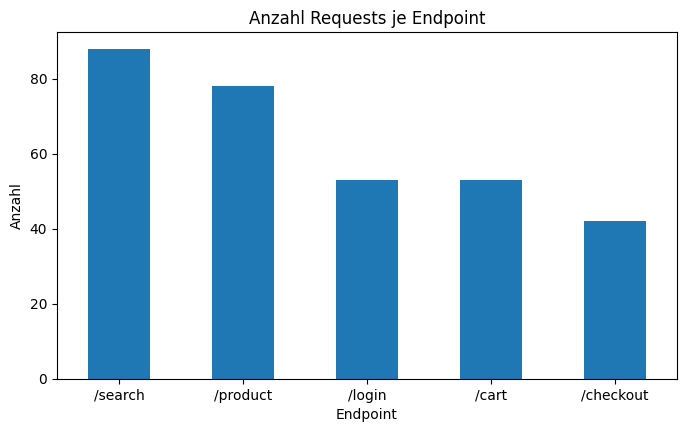

In [13]:
clean["endpoint"].value_counts().plot(kind="bar")
plt.title("Anzahl Requests je Endpoint")
plt.xlabel("Endpoint")
plt.ylabel("Anzahl")
plt.xticks(rotation=0)
plt.show()

### Welche Darstellung passt?

- **Balkendiagramm:** Kategorien und ihre Häufigkeiten
- **Histogramm:** Verteilung einer metrischen Größe
- **Boxplot:** kompakter Vergleich von Verteilungen
- **Streudiagramm:** Zusammenhang zweier metrischer Größen

## 5. Metrische Daten: Lage und Streuung

Wir betrachten die Antwortzeit `response_ms`.

In [14]:
clean["response_ms"].describe()

count     314.000000
mean      223.895541
std       143.965872
min        28.000000
25%       156.700000
50%       196.250000
75%       252.175000
max      1161.600000
Name: response_ms, dtype: float64

In [15]:
x = clean["response_ms"]

print("Mittelwert:          ", round(x.mean(), 1), "ms")
print("Median:              ", round(x.median(), 1), "ms")
print("Standardabweichung:  ", round(x.std(), 1), "ms")
print("25%-Quantil:         ", round(x.quantile(0.25), 1), "ms")
print("75%-Quantil:         ", round(x.quantile(0.75), 1), "ms")

Mittelwert:           223.9 ms
Median:               196.2 ms
Standardabweichung:   144.0 ms
25%-Quantil:          156.7 ms
75%-Quantil:          252.2 ms


### Mittelwert oder Median?

Der Mittelwert reagiert empfindlicher auf extreme Werte.  
Schauen wir uns die langsamsten Requests an.

In [16]:
clean.nlargest(8, "response_ms")[
    ["request_id", "endpoint", "region", "response_ms", "status_code"]
]

,request_id,endpoint,region,response_ms,status_code
175,REQ-0176,/cart,EU-West,1161.6,500
284,REQ-0285,/login,EU-West,1141.7,200
303,REQ-0304,/product,EU-Central,1092.7,200
214,REQ-0215,/product,EU-Central,1075.9,200
167,REQ-0168,/cart,EU-Central,1017.1,500
45,REQ-0046,/cart,EU-West,829.5,200
41,REQ-0042,/product,EU-Central,820.8,200
120,REQ-0121,/product,US-East,715.5,500


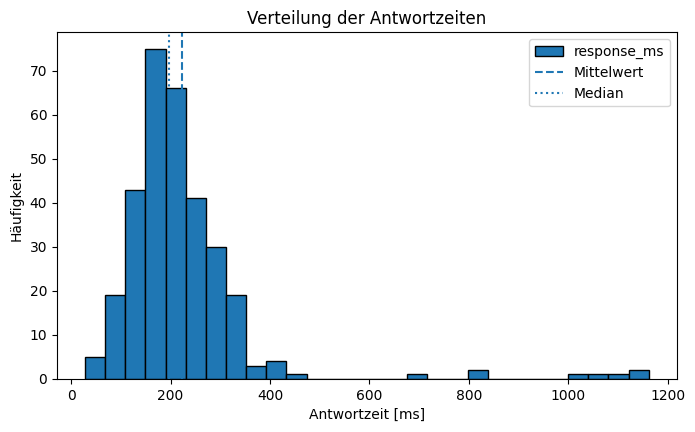

In [17]:
clean["response_ms"].plot.hist(bins=28, edgecolor="black")
plt.axvline(clean["response_ms"].mean(), linestyle="--", label="Mittelwert")
plt.axvline(clean["response_ms"].median(), linestyle=":", label="Median")
plt.title("Verteilung der Antwortzeiten")
plt.xlabel("Antwortzeit [ms]")
plt.ylabel("Häufigkeit")
plt.legend()
plt.show()

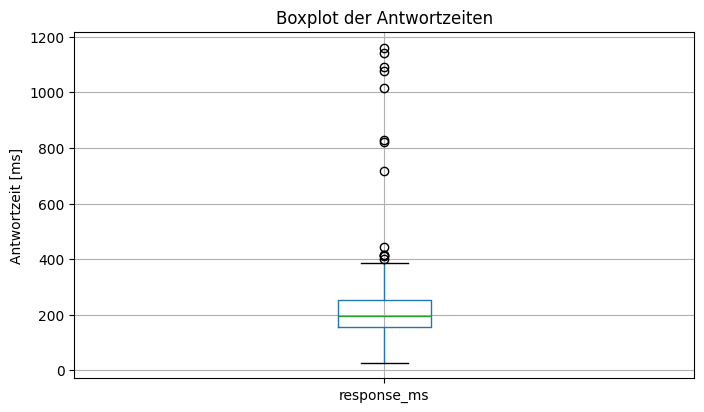

In [18]:
clean[["response_ms"]].boxplot()
plt.title("Boxplot der Antwortzeiten")
plt.ylabel("Antwortzeit [ms]")
plt.show()

**Interpretation:** Bei rechtsschiefen Daten mit einzelnen sehr langsamen Requests liegt der Mittelwert typischerweise über dem Median.

Der Median beantwortet eher: *„Wie lange dauert ein typischer Request?“*  
Der Mittelwert beantwortet eher: *„Wie groß ist die durchschnittliche Last/Verzögerung über alle Requests?“*

## 6. Gruppen vergleichen: `groupby`

Jetzt wird die Analyse interessanter:

> Unterscheiden sich die Antwortzeiten zwischen den Endpoints?

In [19]:
endpoint_stats = (
    clean.groupby("endpoint")["response_ms"]
    .agg(["count", "mean", "median", "std"])
    .sort_values("median")
    .round(1)
)

endpoint_stats

,count,mean,median,std
endpoint,,,,
/login,53,166.1,148.6,147.7
/product,78,229.6,189.5,174.6
/search,88,201.8,197.1,59.3
/cart,53,250.5,207.2,197.8
/checkout,42,299.0,296.1,64.0


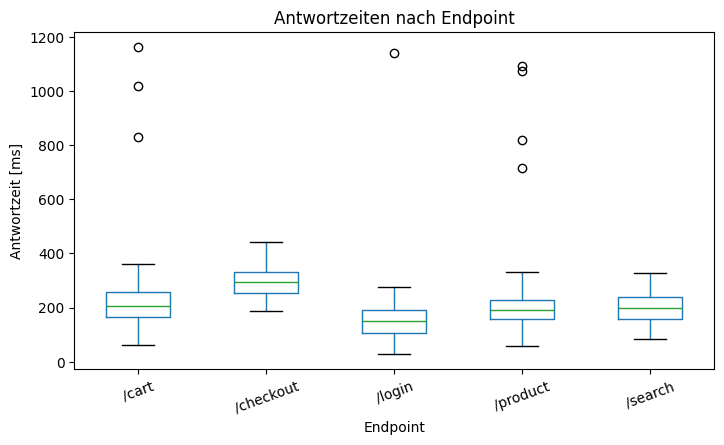

In [20]:
clean.boxplot(column="response_ms", by="endpoint", grid=False)
plt.suptitle("")
plt.title("Antwortzeiten nach Endpoint")
plt.xlabel("Endpoint")
plt.ylabel("Antwortzeit [ms]")
plt.xticks(rotation=20)
plt.show()

### 🧪 Mini-Aufgabe 2

Vergleichen Sie Requests **mit** und **ohne** Cache-Hit.

Berechnen Sie für beide Gruppen:

- Anzahl,
- Mittelwert,
- Median der Antwortzeit.

**Frage:** Reicht dieser Vergleich schon aus, um zu behaupten, dass Caching *kausal* eine bestimmte Anzahl Millisekunden spart?

In [21]:
cache_stats = (
    clean.groupby("cache_hit")["response_ms"]
    .agg(["count", "mean", "median"])
    .round(1)
)
cache_stats

,count,mean,median
cache_hit,,,
False,181,250.4,221.3
True,133,187.8,172.4


**Diskussionspunkt:** Nein. Ein Gruppenunterschied allein beweist keine Kausalität.  
Zum Beispiel werden nicht alle Endpoints gleich häufig gecacht; Endpoint, Region, Payload oder Last können den Vergleich mit beeinflussen.

## 7. Zwei metrische Merkmale: Streudiagramm und Korrelation

Frage:

> Sind größere Payloads mit längeren Antwortzeiten verbunden?

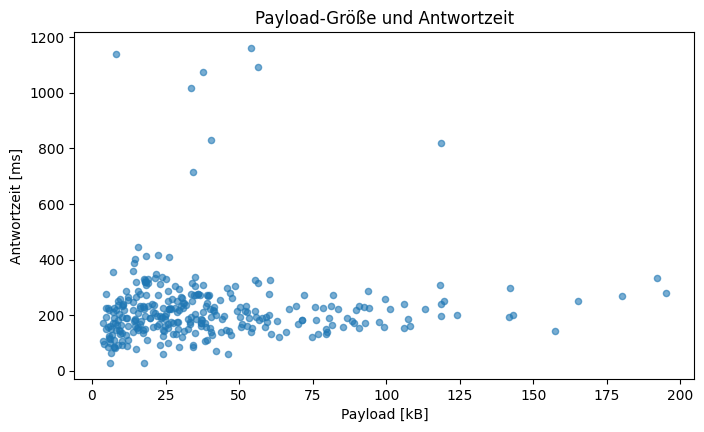

In [22]:
clean.plot.scatter(x="payload_kb", y="response_ms", alpha=0.6)
plt.title("Payload-Größe und Antwortzeit")
plt.xlabel("Payload [kB]")
plt.ylabel("Antwortzeit [ms]")
plt.show()

In [23]:
corr = clean["payload_kb"].corr(clean["response_ms"])
print("Pearson-Korrelation:", round(corr, 3))

Pearson-Korrelation: 0.072


Eine Korrelation nahe `+1` bedeutet einen starken positiven linearen Zusammenhang, nahe `-1` einen starken negativen linearen Zusammenhang und nahe `0` keinen starken **linearen** Zusammenhang.

> **Wichtig:** Korrelation ist kein Beweis für Kausalität.

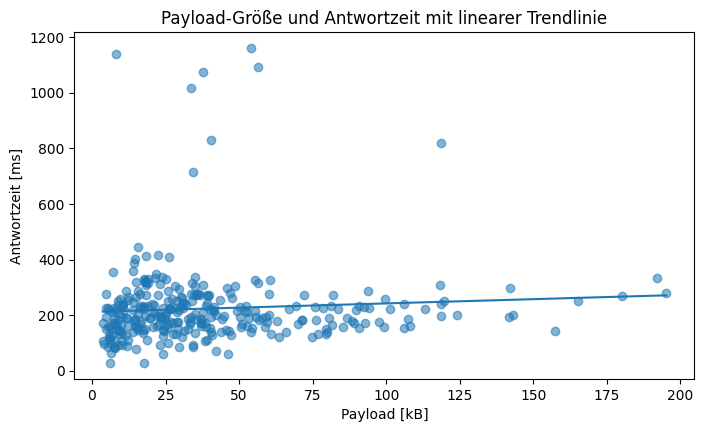

Trendlinie: response_ms ≈ 0.30 · payload_kb + 211.9


In [24]:
# Eine einfache lineare Trendlinie – nur als visuelle Orientierung
x = clean["payload_kb"].to_numpy()
y = clean["response_ms"].to_numpy()

m, b = np.polyfit(x, y, 1)

plt.scatter(x, y, alpha=0.55)
x_line = np.linspace(x.min(), x.max(), 100)
plt.plot(x_line, m * x_line + b)
plt.title("Payload-Größe und Antwortzeit mit linearer Trendlinie")
plt.xlabel("Payload [kB]")
plt.ylabel("Antwortzeit [ms]")
plt.show()

print(f"Trendlinie: response_ms ≈ {m:.2f} · payload_kb + {b:.1f}")

## 8. Warum Stichproben schwanken

Statistik beschäftigt sich oft nicht mit **allen** Daten, sondern mit einer Stichprobe.

Wir ziehen wiederholt nur 30 Requests und berechnen jedes Mal den Mittelwert.

In [25]:
rng = np.random.default_rng(42)

sample_means = []
for _ in range(500):
    sample = clean["response_ms"].sample(n=30, replace=False, random_state=int(rng.integers(1_000_000)))
    sample_means.append(sample.mean())

sample_means = pd.Series(sample_means)
sample_means.describe()

count    500.000000
mean     223.541060
std       25.460108
min      162.013333
25%      204.982500
50%      219.625000
75%      238.046667
max      321.330000
dtype: float64

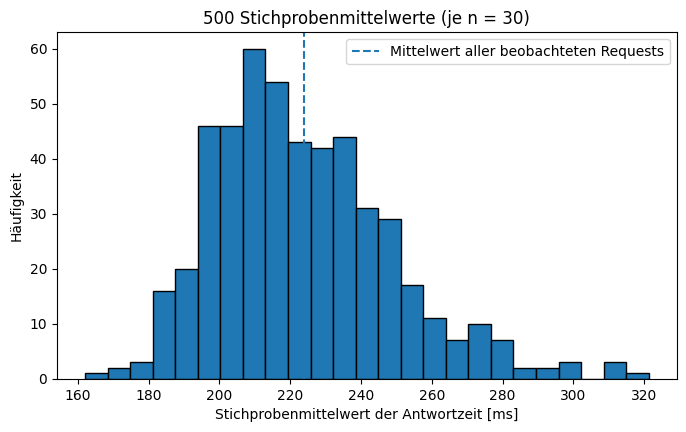

In [26]:
sample_means.plot.hist(bins=25, edgecolor="black")
plt.axvline(clean["response_ms"].mean(), linestyle="--", label="Mittelwert aller beobachteten Requests")
plt.title("500 Stichprobenmittelwerte (je n = 30)")
plt.xlabel("Stichprobenmittelwert der Antwortzeit [ms]")
plt.ylabel("Häufigkeit")
plt.legend()
plt.show()

**Beobachtung:** Obwohl alle Stichproben aus denselben Daten stammen, liefern sie nicht exakt denselben Mittelwert.

Genau hier kommt Wahrscheinlichkeitstheorie ins Spiel:  
Wir wollen verstehen, **wie stark statistische Kennzahlen zufällig schwanken** und welche Schlussfolgerungen aus einer Stichprobe gerechtfertigt sind.

## 9. Abschluss-Challenge

Beantworten Sie mit Python drei Fragen:

1. Welcher Endpoint hat den höchsten **Median** der Antwortzeit?
2. Wie hoch ist der Anteil der Requests mit Statuscode `500` in Prozent?
3. Welche Region hat den höchsten Median der Antwortzeit?

Formulieren Sie zu jeder Zahl einen vollständigen Satz – nicht nur Code.

In [27]:
median_by_endpoint = clean.groupby("endpoint")["response_ms"].median().sort_values(ascending=False)
median_by_endpoint

endpoint
/checkout    296.10
/cart        207.20
/search      197.15
/product     189.50
/login       148.60
Name: response_ms, dtype: float64

In [28]:
error_rate_500 = (clean["status_code"].eq(500).mean() * 100)
print(f"Anteil HTTP 500: {error_rate_500:.1f} %")

Anteil HTTP 500: 4.1 %


In [29]:
median_by_region = clean.groupby("region")["response_ms"].median().sort_values(ascending=False)
median_by_region

region
US-East       273.0
EU-West       192.7
EU-Central    172.0
Name: response_ms, dtype: float64

### Mögliche Formulierungen

- Der Endpoint mit dem höchsten Median ist der erste Eintrag der sortierten Endpoint-Tabelle.
- Der Anteil der Requests mit HTTP 500 beträgt den oben berechneten Prozentwert.
- Die Region mit dem höchsten Median ist der erste Eintrag der sortierten Region-Tabelle.

**Didaktischer Punkt:** Lassen Sie die Studierenden die Sätze selbst formulieren.  
Die Übersetzung von Output in eine sachlich korrekte Aussage ist der statistisch wichtige Teil.

## 10. Take-away

Heute haben wir denselben grundlegenden Analyseprozess mehrfach benutzt:

**Frage → Daten auswählen → Kennzahl/Diagramm → Interpretation**

Python hat uns dabei Arbeit abgenommen. Die statistische Entscheidung bleibt aber bei uns:

- Welche Beobachtungseinheit betrachten wir?
- Welche Art von Merkmal liegt vor?
- Welche Kennzahl beantwortet unsere Frage?
- Welches Diagramm passt?
- Was dürfen wir aus dem Ergebnis wirklich schließen?

### Zum Weiterprobieren

- Gibt es eine „Rush Hour“?
- Sind Fehler-Requests langsamer?
- Unterscheidet sich der Cache-Effekt zwischen `/search` und `/product`?
- Was passiert mit Mittelwert und Median, wenn Sie die fünf langsamsten Requests entfernen?

---

### Bezug zur Statistik-I-Veranstaltung

Der Aufbau orientiert sich an den dort behandelten Themen **Häufigkeiten und Histogramme**, **Lage- und Streuungsmaße**, **Boxplots** und **bivariater Statistik**, überträgt sie aber auf Python/pandas.

# Dozentenhinweise (nicht zwingend gemeinsam durcharbeiten)

## Vorschlag für 75–90 Minuten

| Zeit | Abschnitt | Fokus |
|---:|---|---|
| 0–10 min | 0–2 | Jupyter, Datensatz, statistische Einheit / Merkmale |
| 10–20 min | 3 | Filtern + Mini-Aufgabe 1 |
| 20–35 min | 4–5 | Häufigkeiten, Kennzahlen, Histogramm, Ausreißer |
| 35–50 min | 6 | `groupby`, Boxplot, Cache-Aufgabe |
| 50–65 min | 7 | Scatterplot, Korrelation, Kausalität |
| 65–75 min | 8 | Stichproben-Simulation |
| 75–90 min | 9–10 | Abschluss-Challenge, Diskussion, Puffer |

## Gute Fragen in den Raum

- „Welche Spalte ist eigentlich eine Zahl, aber trotzdem nicht metrisch?“ → `status_code`
- „Warum unterscheidet sich Mittelwert vom Median?“ → Ausreißer / Schiefe
- „Kann ein Balkendiagramm ein Histogramm ersetzen?“ → Kategorien vs. Klassen metrischer Werte
- „Beweist die Korrelation, dass große Payloads die Ursache sind?“ → nein
- „Warum liefern zwei Gruppen von je 30 Requests unterschiedliche Mittelwerte?“ → Stichprobenvariabilität

## Falls nur 45–60 Minuten Zeit sind

Abschnitte **7 (Trendlinie)** und **8 (Stichproben-Simulation)** nur kurz zeigen oder ganz auslassen.